In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Load the dataset
data = pd.read_excel(r'/Users/aldha/accidente-peruanos/data/raw/BBDD ONSV - SINIESTROS FATALES 2021-2025 (preliminar).xlsx', header=4)
print(f'Filas: {data.shape[0]}, Columnas: {data.shape[1]}')
data.head()

Matplotlib is building the font cache; this may take a moment.


Filas: 9106, Columnas: 27


,CÓDIGO SINIESTRO,FECHA SINIESTRO,HORA SINIESTRO,CLASE SINIESTRO,CANTIDAD DE FALLECIDOS,CANTIDAD DE LESIONADOS,CANTIDAD DE VEHICULOS DAÑADOS,DEPARTAMENTO,PROVINCIA,DISTRITO,...,ZONIFICACIÓN,CARACTERÍSTICAS DE VÍA,PERFIL LONGITUDINAL VÍA,SUPERFICIE DE CALZADA,¿EXISTE SEÑAL VERTICAL?,CLASIFICACIÓN DE LA SEÑAL VERTICAL Nº 1,CLASIFICACIÓN DE LA SEÑAL VERTICAL Nº 2,¿EXISTE SEÑAL HORIZONTAL?,CAUSA FACTOR PRINCIPAL,CAUSA ESPECÍFICA
0,A-2021-01-23,01/01/2021,04:40,DESPISTE,1,0,1.0,LIMA,HUARAL,HUARAL,...,RURAL,TRAMO RECTO,PLANA,TROCHA,NaN,NaN,NaN,NaN,EN PROCESO DE INVESTIGACIÓN,NO CUENTA CON CAUSA ESPECIFICA
1,A-2021-01-248,01/01/2021,05:45,DESPISTE,1,3,0.0,LIMA,LIMA,PACHACAMAC,...,INDUSTRIAL,TRAMO RECTO,PLANA,ASFALTADA,NaN,NaN,NaN,NaN,IMPRUDENCIA DEL CONDUCTOR,CONDUCIR EN ESTADO DE EBRIEDAD Y/O DROGADICCIÓN
2,A-2021-01-38,01/01/2021,06:00,ATROPELLO FUGA,2,0,NaN,LA LIBERTAD,VIRU,VIRU,...,COMERCIAL,TRAMO RECTO,PLANA,ASFALTADA,NaN,NaN,NaN,NaN,EN PROCESO DE INVESTIGACIÓN,NO CUENTA CON CAUSA ESPECIFICA
3,A-2021-01-39,01/01/2021,07:00,CHOQUE,1,0,2.0,LA LIBERTAD,VIRU,VIRU,...,RURAL,TRAMO RECTO,PLANA,ASFALTADA,NaN,NaN,NaN,NaN,IMPRUDENCIA DEL CONDUCTOR,GIRAR IMPRUDENTEMENTE
4,A-2021-01-254,01/01/2021,14:00,ATROPELLO,1,1,0.0,LIMA,LIMA,VILLA MARIA DEL TRIUNFO,...,INDUSTRIAL,TRAMO RECTO,PLANA,ASFALTADA,NaN,NaN,NaN,NaN,IMPRUDENCIA DEL CONDUCTOR,CONDUCIR EN ESTADO DE EBRIEDAD Y/O DROGADICCIÓN


In [2]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9106 entries, 0 to 9105
Data columns (total 27 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   CÓDIGO SINIESTRO                         9106 non-null   object 
 1   FECHA SINIESTRO                          9106 non-null   object 
 2   HORA SINIESTRO                           9106 non-null   object 
 3   CLASE SINIESTRO                          9106 non-null   object 
 4   CANTIDAD DE FALLECIDOS                   9106 non-null   int64  
 5   CANTIDAD DE LESIONADOS                   9106 non-null   int64  
 6   CANTIDAD DE VEHICULOS DAÑADOS            6293 non-null   float64
 7   DEPARTAMENTO                             9106 non-null   object 
 8   PROVINCIA                                9106 non-null   object 
 9   DISTRITO                                 9106 non-null   object 
 10  ZONA                                     9068 no

In [3]:
data.columns.tolist()

['CÓDIGO SINIESTRO',
 'FECHA SINIESTRO',
 'HORA SINIESTRO',
 'CLASE SINIESTRO',
 'CANTIDAD DE FALLECIDOS',
 'CANTIDAD DE LESIONADOS',
 'CANTIDAD DE VEHICULOS DAÑADOS',
 'DEPARTAMENTO',
 'PROVINCIA',
 'DISTRITO',
 'ZONA',
 'TIPO DE VÍA',
 'RED VIAL',
 'COD CARRETERA',
 'COORDENADAS LATITUD',
 'COORDENADAS  LONGITUD',
 'CONDICIÓN CLIMÁTICA',
 'ZONIFICACIÓN',
 'CARACTERÍSTICAS DE VÍA',
 'PERFIL LONGITUDINAL VÍA',
 'SUPERFICIE DE CALZADA',
 '¿EXISTE SEÑAL VERTICAL?',
 'CLASIFICACIÓN DE LA SEÑAL VERTICAL Nº 1',
 'CLASIFICACIÓN DE LA SEÑAL VERTICAL Nº 2',
 '¿EXISTE SEÑAL HORIZONTAL?',
 'CAUSA FACTOR PRINCIPAL',
 'CAUSA ESPECÍFICA']

In [4]:
data['DEPARTAMENTO'].unique()

array(['LIMA', 'LA LIBERTAD', 'SAN MARTIN', 'LAMBAYEQUE', 'PIURA',
       'JUNIN', 'PUNO', 'ANCASH', 'AREQUIPA', 'CUSCO', 'APURIMAC', 'ICA',
       'HUANUCO', 'TACNA', 'MOQUEGUA', 'PASCO', 'CAJAMARCA', 'CALLAO',
       'AMAZONAS', 'HUANCAVELICA', 'AYACUCHO', 'UCAYALI', 'MADRE DE DIOS',
       'LORETO', 'TUMBES'], dtype=object)

In [5]:
# Cantidad de nulos por columna, ordenado de mayor a menor
nulos = data.isnull().sum().sort_values(ascending=False)
print(nulos[nulos > 0])

CLASIFICACIÓN DE LA SEÑAL VERTICAL Nº 2    8572
CLASIFICACIÓN DE LA SEÑAL VERTICAL Nº 1    7790
¿EXISTE SEÑAL HORIZONTAL?                  7090
¿EXISTE SEÑAL VERTICAL?                    7090
CANTIDAD DE VEHICULOS DAÑADOS              2813
PERFIL LONGITUDINAL VÍA                     424
CONDICIÓN CLIMÁTICA                         423
SUPERFICIE DE CALZADA                       423
CARACTERÍSTICAS DE VÍA                      423
ZONIFICACIÓN                                423
CAUSA ESPECÍFICA                             82
ZONA                                         38
COD CARRETERA                                 1
dtype: int64


In [6]:
data = data.drop(columns=['CLASIFICACIÓN DE LA SEÑAL VERTICAL Nº 2','CLASIFICACIÓN DE LA SEÑAL VERTICAL Nº 1','¿EXISTE SEÑAL HORIZONTAL?','¿EXISTE SEÑAL VERTICAL?'])
print(f"Columnas restantes: {data.shape[1]}")

Columnas restantes: 23


In [7]:
print(data['FECHA SINIESTRO'].head())
print(data['FECHA SINIESTRO'].dtype)
print()
print(data['HORA SINIESTRO'].head())
print(data['HORA SINIESTRO'].dtype)

0    01/01/2021
1    01/01/2021
2    01/01/2021
3    01/01/2021
4    01/01/2021
Name: FECHA SINIESTRO, dtype: object
object

0    04:40
1    05:45
2    06:00
3    07:00
4    14:00
Name: HORA SINIESTRO, dtype: object
object


In [9]:
#Fecha viene como texto, lo convertimos a fecha real para operaciones
data['FECHA SINIESTRO'] = pd.to_datetime(data['FECHA SINIESTRO'], format='%d/%m/%Y', errors='coerce')

#Extraer mes y día de la semana
data['MES'] = data['FECHA SINIESTRO'].dt.month
data['DIA_SEMANA'] = data['FECHA SINIESTRO'].dt.day_name()

#Extraemos hora
data['HORA'] = pd.to_datetime(data['HORA SINIESTRO'], format='%H:%M', errors='coerce').dt.hour

print (data[['FECHA SINIESTRO', 'MES', 'DIA_SEMANA', 'HORA']].head())
print (data['HORA SINIESTRO'].head())

  FECHA SINIESTRO  MES DIA_SEMANA  HORA
0      2021-01-01    1     Friday     4
1      2021-01-01    1     Friday     5
2      2021-01-01    1     Friday     6
3      2021-01-01    1     Friday     7
4      2021-01-01    1     Friday    14
0    04:40
1    05:45
2    06:00
3    07:00
4    14:00
Name: HORA SINIESTRO, dtype: object


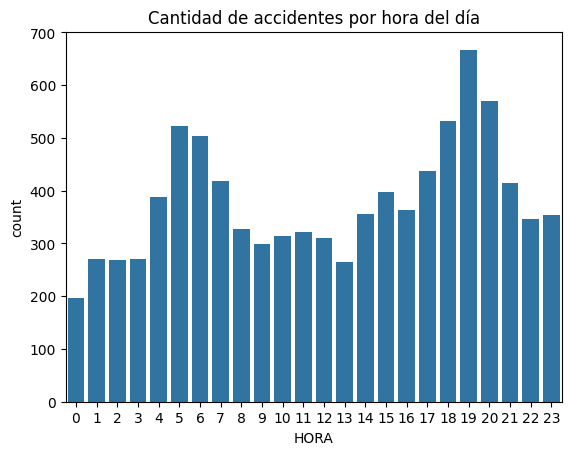

In [10]:
sns.countplot(data=data, x='HORA')
plt.title('Cantidad de accidentes por hora del día')
plt.show()

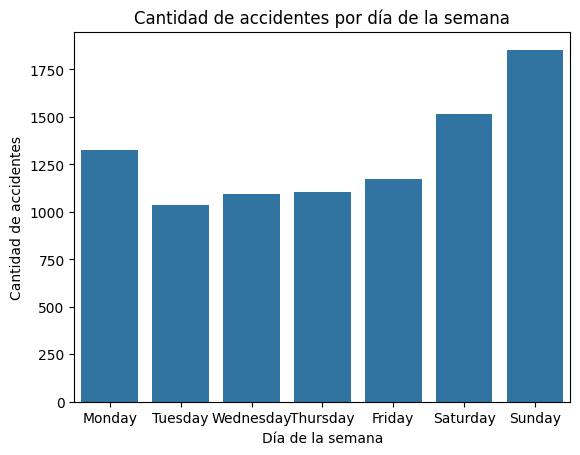

In [11]:
# Cantidad de accidentes por día de la semana
orden_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.countplot(data=data, x='DIA_SEMANA', order=orden_dias)
plt.title('Cantidad de accidentes por día de la semana')
plt.ylabel('Cantidad de accidentes')
plt.xlabel('Día de la semana')
plt.show()

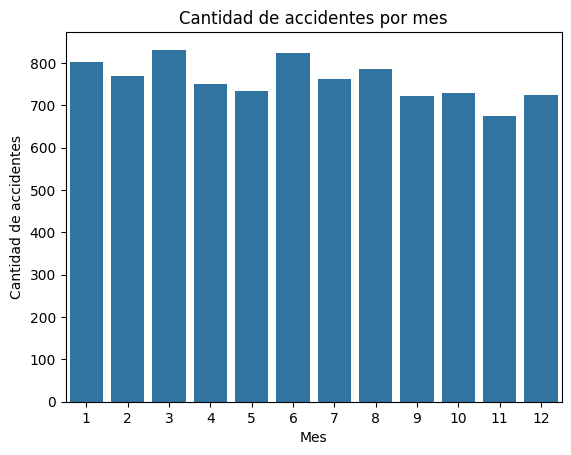

In [12]:
# Cantida de accidentes por mes
sns.countplot(data=data, x='MES')
plt.title('Cantidad de accidentes por mes')
plt.ylabel('Cantidad de accidentes')
plt.xlabel('Mes')
plt.show()

Hasta el momento se puede concluir que los picos de accidentes están entre sábados a lunes entre las 5-7am y 18-20 horas. No hay mucha diferencia entre meses por lo que consideraremos normal

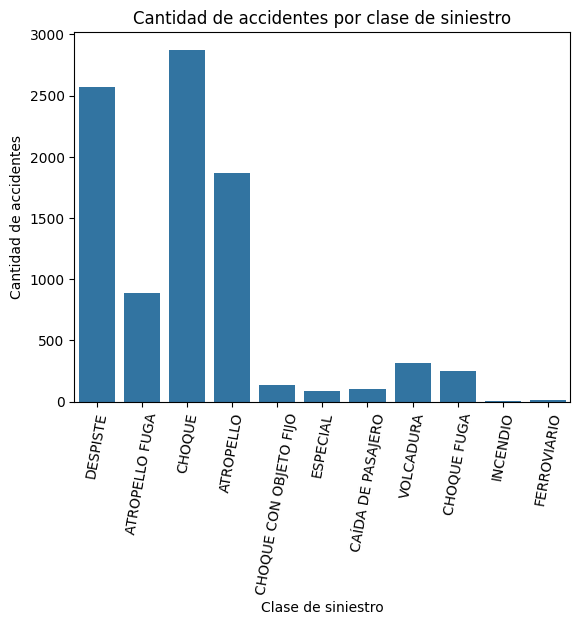

In [17]:
#Gráfico de cantidad de accidentes por clase de siniestro
sns.countplot(data=data, x='CLASE SINIESTRO')
plt.title('Cantidad de accidentes por clase de siniestro')
plt.ylabel('Cantidad de accidentes')
plt.xlabel('Clase de siniestro')
plt.xticks(rotation=80)
plt.show()

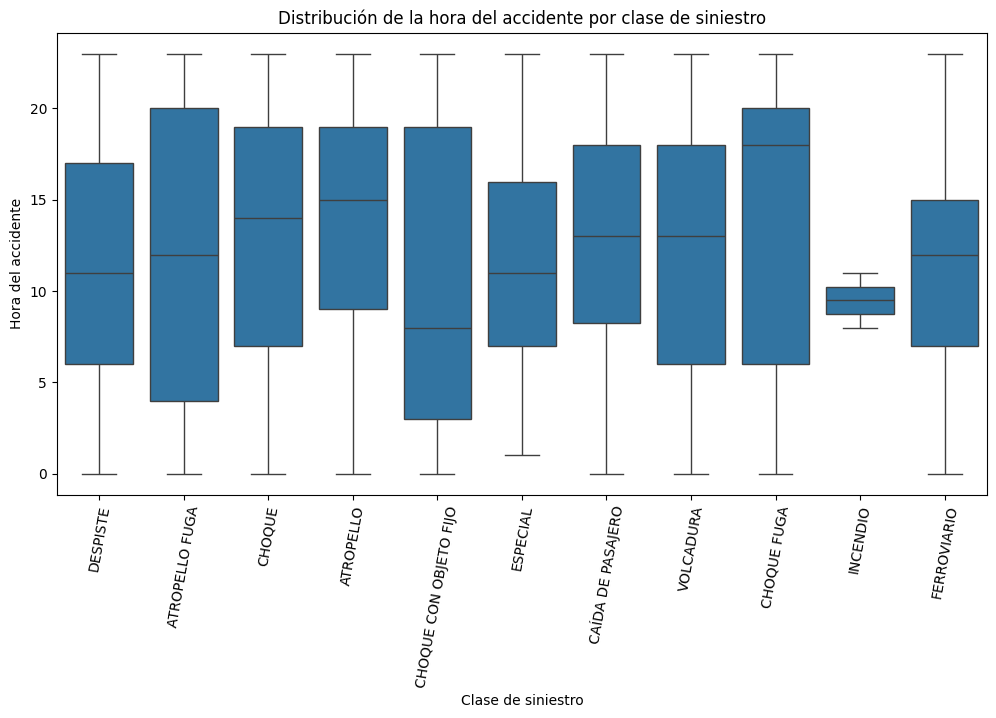

In [18]:
#Gráfico de boxplot de la variable HORA por CLASE SINIESTRO
plt.figure(figsize=(12,6))
sns.boxplot(data=data, x='CLASE SINIESTRO', y='HORA')
plt.title('Distribución de la hora del accidente por clase de siniestro')
plt.xticks(rotation=80)
plt.ylabel('Hora del accidente')
plt.xlabel('Clase de siniestro')
plt.show()

In [19]:
data.columns.tolist()

['CÓDIGO SINIESTRO',
 'FECHA SINIESTRO',
 'HORA SINIESTRO',
 'CLASE SINIESTRO',
 'CANTIDAD DE FALLECIDOS',
 'CANTIDAD DE LESIONADOS',
 'CANTIDAD DE VEHICULOS DAÑADOS',
 'DEPARTAMENTO',
 'PROVINCIA',
 'DISTRITO',
 'ZONA',
 'TIPO DE VÍA',
 'RED VIAL',
 'COD CARRETERA',
 'COORDENADAS LATITUD',
 'COORDENADAS  LONGITUD',
 'CONDICIÓN CLIMÁTICA',
 'ZONIFICACIÓN',
 'CARACTERÍSTICAS DE VÍA',
 'PERFIL LONGITUDINAL VÍA',
 'SUPERFICIE DE CALZADA',
 'CAUSA FACTOR PRINCIPAL',
 'CAUSA ESPECÍFICA',
 'MES',
 'DIA_SEMANA',
 'HORA']

In [23]:
# Se realizará un mapa de calor con las variables de coordenadas, pero primero verificamos que vengan limpias y sin valores nulos
print(data['COORDENADAS LATITUD'].dtype)
print(data['COORDENADAS  LONGITUD'].dtype)
print()
print(data[['COORDENADAS LATITUD', 'COORDENADAS  LONGITUD']].describe())
print()
print(data[['COORDENADAS LATITUD', 'COORDENADAS  LONGITUD']].isnull().sum())

float64
object

       COORDENADAS LATITUD
count          9106.000000
mean            -11.299475
std               3.636620
min             -18.305434
25%             -13.836632
50%             -12.029306
75%              -8.019364
max              -3.482889

COORDENADAS LATITUD      0
COORDENADAS  LONGITUD    0
dtype: int64


In [24]:
print(data['COORDENADAS  LONGITUD'].head(10))
print(data['COORDENADAS LATITUD'].head(10))

0    -77.25554675971524
1            -76.859412
2            -78.754544
3            -78.772242
4            -76.953426
5            -77.171368
6            -79.903582
7    -80.65128116025174
8           -76.0752901
9            -70.204043
Name: COORDENADAS  LONGITUD, dtype: object
0   -11.482879
1   -12.229400
2    -8.414865
3    -8.432617
4   -12.164406
5    -6.063829
6    -6.680472
7    -5.164956
8   -11.591655
9   -14.921160
Name: COORDENADAS LATITUD, dtype: float64


In [25]:
#Convertir coordenadas a numéricas
data['COORDENADAS  LONGITUD'] = pd.to_numeric(data['COORDENADAS  LONGITUD'], errors='coerce')

print(data['COORDENADAS  LONGITUD'].dtype)
print(data['COORDENADAS  LONGITUD'].isnull().sum())
print(data['COORDENADAS  LONGITUD'].describe())

float64
1
count    9105.000000
mean      -75.657871
std         3.258462
min       -81.288901
25%       -78.112905
50%       -76.920455
75%       -72.225810
max       -68.953099
Name: COORDENADAS  LONGITUD, dtype: float64


In [26]:
print(data['COORDENADAS  LONGITUD'].head(10))
print(data['COORDENADAS LATITUD'].head(10))

0   -77.255547
1   -76.859412
2   -78.754544
3   -78.772242
4   -76.953426
5   -77.171368
6   -79.903582
7   -80.651281
8   -76.075290
9   -70.204043
Name: COORDENADAS  LONGITUD, dtype: float64
0   -11.482879
1   -12.229400
2    -8.414865
3    -8.432617
4   -12.164406
5    -6.063829
6    -6.680472
7    -5.164956
8   -11.591655
9   -14.921160
Name: COORDENADAS LATITUD, dtype: float64


In [27]:
# Se realizará un mapa de calor con las variables de coordenadas, pero primero verificamos que vengan limpias y sin valores nulos
print(data['COORDENADAS LATITUD'].dtype)
print(data['COORDENADAS  LONGITUD'].dtype)
print()
print(data[['COORDENADAS LATITUD', 'COORDENADAS  LONGITUD']].describe())
print()
print(data[['COORDENADAS LATITUD', 'COORDENADAS  LONGITUD']].isnull().sum())

float64
float64

       COORDENADAS LATITUD  COORDENADAS  LONGITUD
count          9106.000000            9105.000000
mean            -11.299475             -75.657871
std               3.636620               3.258462
min             -18.305434             -81.288901
25%             -13.836632             -78.112905
50%             -12.029306             -76.920455
75%              -8.019364             -72.225810
max              -3.482889             -68.953099

COORDENADAS LATITUD      0
COORDENADAS  LONGITUD    1
dtype: int64


In [30]:
import folium
from folium.plugins import HeatMap

#Eliminamos filas sin coordenadas validas
data_mapa = data.dropna(subset=['COORDENADAS LATITUD', 'COORDENADAS  LONGITUD'])

# Creamos un mapa centrado en Perú
mapa = folium.Map(location=[-9.19, -75.0152], zoom_start=5)

#Preparamos la lista de coordenadas para el HeatMap
coordenadas = data_mapa[['COORDENADAS LATITUD', 'COORDENADAS  LONGITUD']].values.tolist()

# Agregamos el HeatMap al mapa
HeatMap(coordenadas, radius=8).add_to(mapa)
# Mostramos el mapa
mapa.save('../dashboard/mapa_calor_accidentes.html')
print("Mapa de calor guardado")

Mapa de calor guardado
